In [1]:
# Repo-root bootstrap: makes source/ importable and data/models paths absolute
# regardless of where the notebook server was started.
import sys
import pathlib

try:
    ROOT = pathlib.Path(__file__).resolve().parents[2]
except NameError:  # __file__ not defined in some environments (e.g. Jupyter console)
    ROOT = pathlib.Path.cwd()
    while not (ROOT / 'source').exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'code' / '04_ml'))

# KI-HMM: predictions vs raw signal

Visual comparison of the novel kinetics-informed neural HMM (`torch_models.py`, trained by `train_kihmm.py`) against the raw test signal and the exact kinetic decoder, on frozen `synth_v1` traces.

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import benchmark as B
import kinetics as K
import torch_models as T

model = T.KIHMM().to(T.DEVICE)
model.load_state_dict(torch.load(str(ROOT / 'code' / '04_ml' / 'models' / 'kihmm_synth_v1.pt'), map_location=T.DEVICE)['model'])
model.eval()
test = B.load_split('test')
FIG = ROOT / 'code' / '04_ml' / 'results' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
print('model loaded on', T.DEVICE)

model loaded on cuda


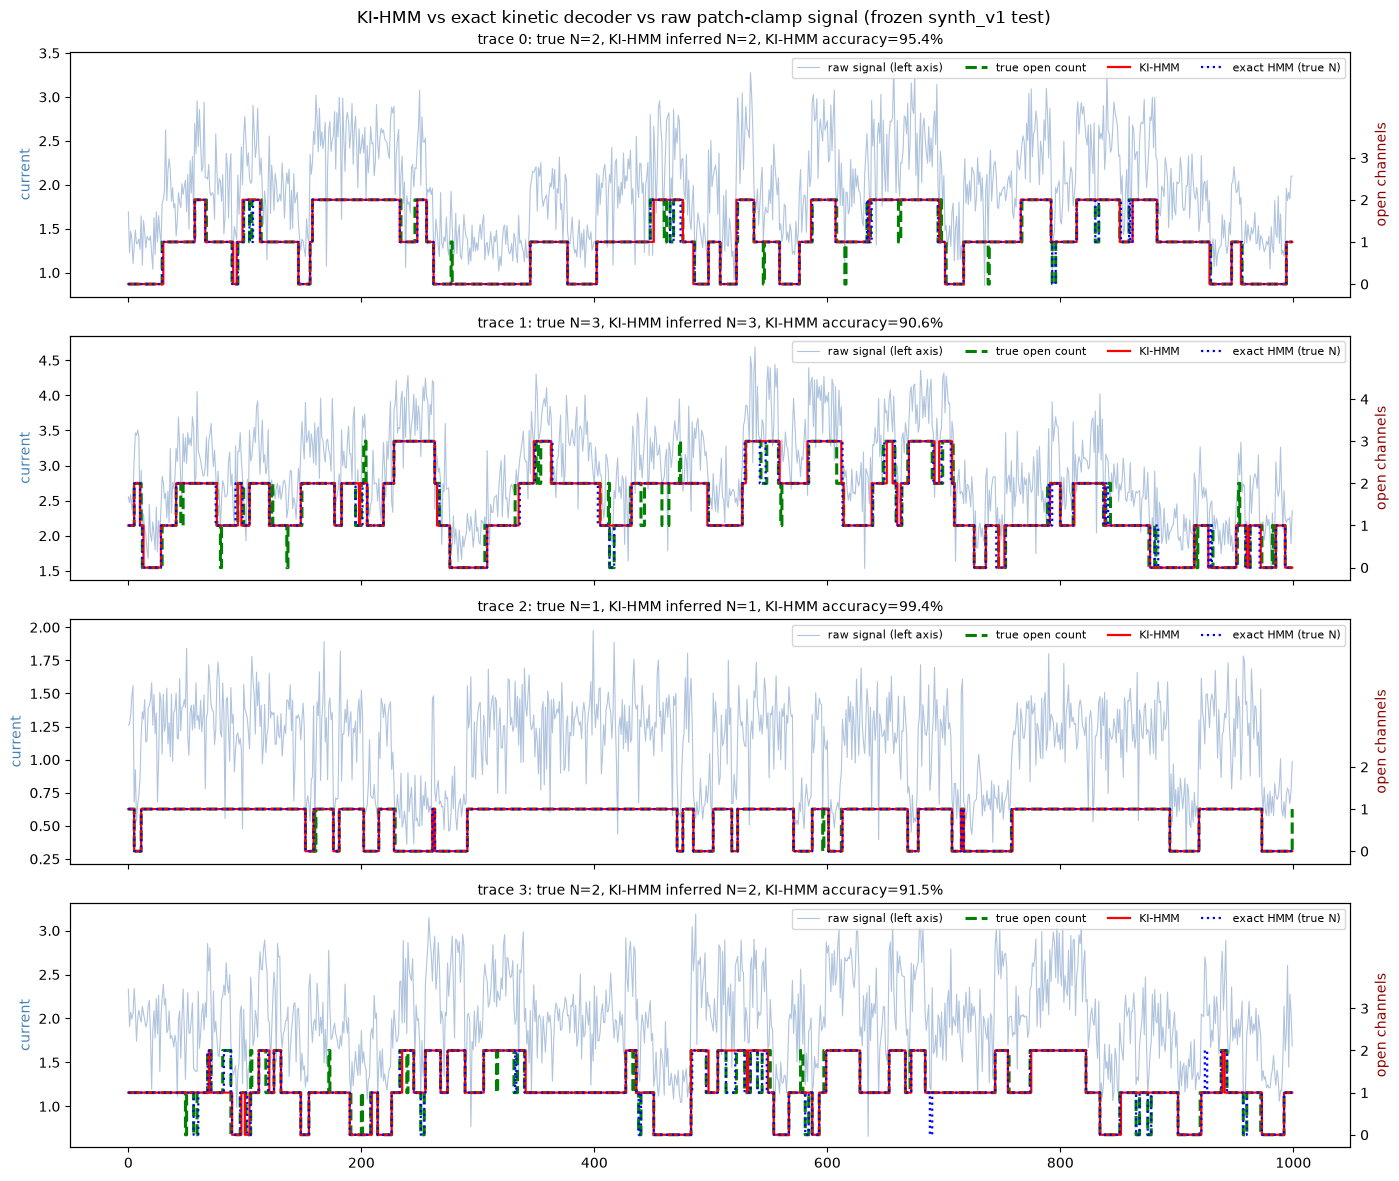

In [3]:
cache = {}
def exact_loader(N):
    if N not in cache:
        g = K.default_grid(N)
        cache[N] = (g, K.emission_log_densities(N, g))
    return cache[N]

def trace_predictions(i):
    x = test['X_s1'][i]
    n_true = int(test['N'][i])
    n_hat, states, _, _ = T.infer_n(model, torch.tensor(x[None, :], dtype=torch.float32, device=T.DEVICE))
    kihmm = states[0].cpu().numpy()
    g, logE = exact_loader(n_true)          # exact decoder given the true N (upper bound view)
    exact, _ = K.decode_open_count(x, n_true, grid=g, logE=logE)
    return x, test['y'][i], kihmm, exact, n_true, int(n_hat[0])

idxs = [0, 1, 2, 3]
fig, axes = plt.subplots(len(idxs), 1, figsize=(14, 12), sharex=True)
for ax, i in zip(np.atleast_1d(axes), idxs):
    x, y, kihmm, exact, n_true, n_hat = trace_predictions(i)
    ax.plot(x, color='lightsteelblue', lw=0.8, label='raw signal (left axis)')
    ax.set_ylabel('current', color='steelblue')
    ax2 = ax.twinx()
    ax2.step(np.arange(len(y)), y, color='green', ls='--', lw=2.2, where='post', label='true open count')
    ax2.step(np.arange(len(kihmm)), kihmm, color='red', lw=1.6, where='post', label='KI-HMM')
    ax2.step(np.arange(len(exact)), exact, color='blue', ls=':', lw=1.6, where='post', label='exact HMM (true N)')
    ax2.set_ylim(-0.3, 5.5)
    ax2.set_yticks(range(0, n_true + 2))
    ax2.set_ylabel('open channels', color='darkred')
    acc = np.mean(kihmm == y)
    ax.set_title(f'trace {i}: true N={n_true}, KI-HMM inferred N={n_hat}, KI-HMM accuracy={acc:.1%}', fontsize=10)
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=8, ncol=4)
fig.suptitle('KI-HMM vs exact kinetic decoder vs raw patch-clamp signal (frozen synth_v1 test)', fontsize=12)
fig.tight_layout()
fig.savefig(str(ROOT / 'code' / '04_ml' / 'results' / 'figures' / 'kihmm_predictions.png'), dpi=130)
plt.show()

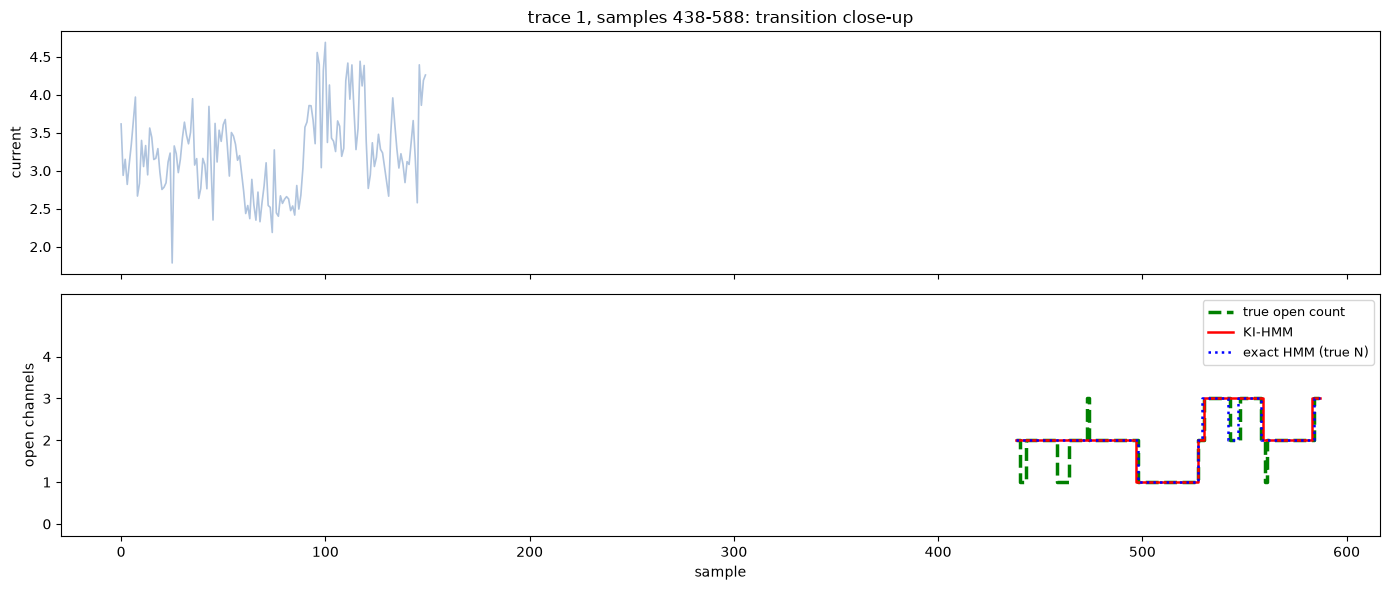

In [4]:
# Zoom on a state transition to show the smoothing effect
i = 1
x, y, kihmm, exact, n_true, n_hat = trace_predictions(i)
changes = np.flatnonzero(np.diff(y) != 0) + 1
t0 = max(0, changes[len(changes) // 2] - 60)
sl = slice(t0, t0 + 150)

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax.plot(x[sl], color='lightsteelblue', lw=1.2, label='raw signal')
ax.set_ylabel('current')
ax2.step(np.arange(len(y))[sl], y[sl], color='green', ls='--', lw=2.5, where='post', label='true open count')
ax2.step(np.arange(len(kihmm))[sl], kihmm[sl], color='red', lw=1.8, where='post', label='KI-HMM')
ax2.step(np.arange(len(exact))[sl], exact[sl], color='blue', ls=':', lw=1.8, where='post', label='exact HMM (true N)')
ax2.set_ylim(-0.3, 5.5)
ax2.set_yticks(range(0, n_true + 2))
ax2.set_ylabel('open channels')
ax2.set_xlabel('sample')
ax2.legend(fontsize=9)
ax.set_title(f'trace {i}, samples {sl.start}-{sl.stop}: transition close-up')
fig.tight_layout()
fig.savefig(str(ROOT / 'code' / '04_ml' / 'results' / 'figures' / 'kihmm_prediction_zoom.png'), dpi=140)
plt.show()